1. Importa las librerías necesarias y la base de datos, y realiza un análisis por variable
usando visualizaciones. Debes considerar las posibles correlaciones y representarlas
en un heatmap.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
                              roc_auc_score, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Carga de datos
df = pd.read_csv('telecom_churn.csv')

print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (3333, 11)


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [2]:
# Información general y distribución de la variable objetivo
print('=== Información general ===')
df.info()
print()
print('=== Distribución de Churn ===')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100, '%')

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB

=== Distribución de Churn ===
Churn
0    2850
1     483
Name: count, dtype: int64
Churn
0    85.5
1    14.5
Name: proportion, dtype: float64 %


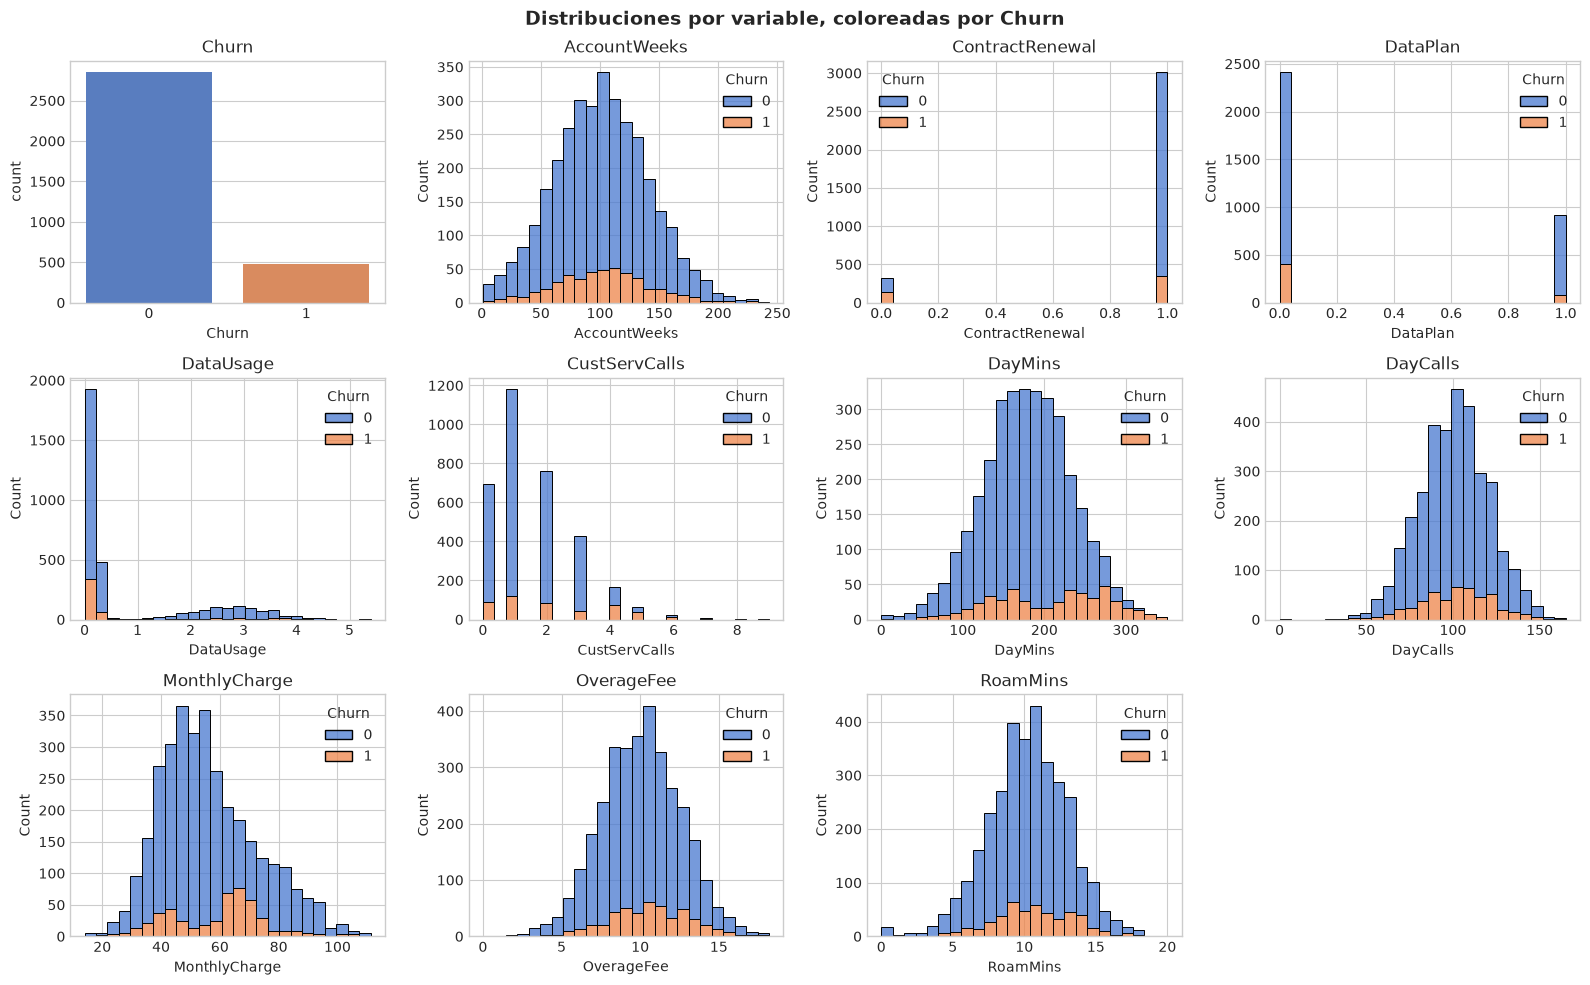

In [3]:
# Distribuciones de todas las variables numéricas
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    if col == 'Churn':
        sns.countplot(x=df[col], ax=axes[i], hue=df[col], legend=False)
    else:
        sns.histplot(data=df, x=col, hue='Churn', ax=axes[i], bins=25, multiple='stack')
    axes[i].set_title(col)

# Ocultar el subplot vacío (11 variables en grilla de 12)
axes[-1].axis('off')

plt.suptitle('Distribuciones por variable, coloreadas por Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

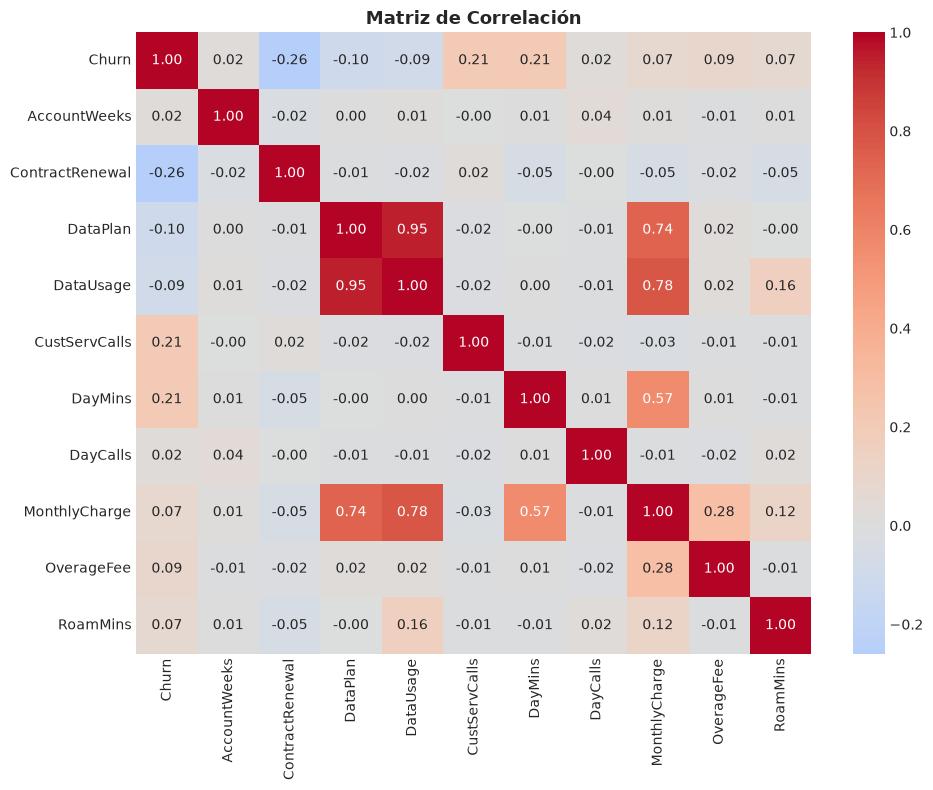

=== Correlación con Churn (ordenada) ===
Churn              1.000000
CustServCalls      0.208750
DayMins            0.205151
OverageFee         0.092812
MonthlyCharge      0.072313
RoamMins           0.068239
DayCalls           0.018459
AccountWeeks       0.016541
DataUsage         -0.087195
DataPlan          -0.102148
ContractRenewal   -0.259852
Name: Churn, dtype: float64


In [4]:
# Heatmap de correlaciones
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax
)
ax.set_title('Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Correlación con Churn (ordenada) ===')
print(corr_matrix['Churn'].sort_values(ascending=False))

Lectura de correlaciones con Churn
Correlaciones positivas (más llamadas/gasto = más riesgo de irse):

CustServCalls (0.209) — más llamadas al servicio al cliente = más frustración = mayor probabilidad de renuncia. Muy intuitivo.
DayMins (0.205) — clientes que usan más minutos diurnos tienden a irse más — quizás porque son usuarios intensivos más sensibles al precio/calidad.
OverageFee (0.093) — cargos por exceso también se asocian levemente con churn.
Correlaciones negativas (más compromiso = menos riesgo):

ContractRenewal (-0.260) — la más fuerte de todas. Clientes que renovaron contrato recientemente tienen mucho menos riesgo de irse — coherente con lo que vimos en el desafío de churn de telecomunicaciones anterior (contrato = compromiso = retención).
DataPlan (-0.102) — tener plan de datos reduce el riesgo de churn, posiblemente porque agrega valor percibido al servicio.
Correlaciones muy débiles: DayCalls y AccountWeeks prácticamente no tienen relación lineal con Churn — variables candidatas a tener menor importancia en los modelos.

2. Desarrolla un modelo de árbol de decisión sin modificar sus hiper parámetros y
despliega sus métricas de desempeño. Luego, mejora este modelo de forma de
evitar el overfitting usando búsqueda por grilla con 5 kfold:
max_depth: [5, 10, 15, 20, 25]
min_samples_split: [0.01, 0.02, 0.03, 0.04]
Da a conocer los mejores hiper parámetros encontrados y el desempeño del modelo,
tanto en los datos de entrenamiento como en los de test.

In [5]:
# Split train/test - se usará para todos los modelos del desafío
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} clientes')
print(f'Prueba: {X_test.shape[0]} clientes')
print()
print('Proporción Churn en train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Proporción Churn en test:', y_test.value_counts(normalize=True).round(3).to_dict())

Entrenamiento: 2666 clientes
Prueba: 667 clientes

Proporción Churn en train: {0: 0.855, 1: 0.145}
Proporción Churn en test: {0: 0.855, 1: 0.145}


In [6]:
# Árbol de Decisión SIN optimizar hiperparámetros
tree_base = DecisionTreeClassifier(random_state=42)
tree_base.fit(X_train, y_train)

y_pred_train = tree_base.predict(X_train)
y_pred_test = tree_base.predict(X_test)

print('=== Árbol de Decisión SIN optimizar ===')
print('\n--- Entrenamiento ---')
print(classification_report(y_train, y_pred_train))
print('\n--- Test ---')
print(classification_report(y_test, y_pred_test))

=== Árbol de Decisión SIN optimizar ===

--- Entrenamiento ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2280
           1       1.00      1.00      1.00       386

    accuracy                           1.00      2666
   macro avg       1.00      1.00      1.00      2666
weighted avg       1.00      1.00      1.00      2666


--- Test ---
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       570
           1       0.64      0.59      0.61        97

    accuracy                           0.89       667
   macro avg       0.79      0.77      0.78       667
weighted avg       0.89      0.89      0.89       667



In [7]:
# GridSearchCV para Árbol de Decisión
params_tree = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [0.01, 0.02, 0.03, 0.04]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params_tree,
    cv=5,
    scoring='f1'
)
grid_tree.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_tree.best_params_)
print('Mejor F1 en CV:', round(grid_tree.best_score_, 4))

Mejores hiperparámetros: {'max_depth': 15, 'min_samples_split': 0.03}
Mejor F1 en CV: 0.734


In [8]:
# Evaluación del árbol optimizado
y_pred_train_opt = grid_tree.predict(X_train)
y_pred_test_opt = grid_tree.predict(X_test)

print('=== Árbol de Decisión OPTIMIZADO ===')
print('\n--- Entrenamiento ---')
print(classification_report(y_train, y_pred_train_opt))
print('\n--- Test ---')
print(classification_report(y_test, y_pred_test_opt))

=== Árbol de Decisión OPTIMIZADO ===

--- Entrenamiento ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      2280
           1       0.86      0.70      0.77       386

    accuracy                           0.94      2666
   macro avg       0.90      0.84      0.87      2666
weighted avg       0.94      0.94      0.94      2666


--- Test ---
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       570
           1       0.68      0.56      0.61        97

    accuracy                           0.90       667
   macro avg       0.81      0.76      0.78       667
weighted avg       0.89      0.90      0.89       667



Árbol sin optimizar vs optimizado
Train Accuracy	Train F1 (Churn)	Test Accuracy	Test F1 (Churn)
Sin optimizar	1.00	1.00	0.89	0.61
Optimizado	    0.94	0.77	0.90	0.61

El GridSearch redujo drásticamente el overfitting — la brecha entre train y test pasó de "100% vs 89%" a "94% vs 90%", mucho más saludable. El modelo optimizado generaliza mejor, aunque el F1 de la clase minoritaria en test se mantiene igual (0.61) — el árbol individual sigue teniendo dificultad para detectar consistentemente a los clientes que renuncian, algo esperable dado el desbalance de clases.

3. Balancea las clases usando SMOTE para el conjunto de entrenamiento. Luego, aplica
un modelo de Bagging con 200 estimadores y muestra las métricas sobre el conjunto
de test.


In [9]:
from imblearn.over_sampling import SMOTE

# Balancear clases usando SMOTE - SOLO en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Distribución ANTES de SMOTE:')
print(y_train.value_counts())
print()
print('Distribución DESPUÉS de SMOTE:')
print(y_train_smote.value_counts())

Distribución ANTES de SMOTE:
Churn
0    2280
1     386
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
Churn
0    2280
1    2280
Name: count, dtype: int64


In [10]:
# Bagging con 200 estimadores, entrenado sobre datos balanceados con SMOTE
bagging_model = BaggingClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_smote, y_train_smote)

y_pred_bagging = bagging_model.predict(X_test)

print('=== Bagging (200 estimadores) con SMOTE ===')
print(classification_report(y_test, y_pred_bagging))

=== Bagging (200 estimadores) con SMOTE ===
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       570
           1       0.54      0.70      0.61        97

    accuracy                           0.87       667
   macro avg       0.75      0.80      0.77       667
weighted avg       0.89      0.87      0.88       667



El Recall subió de 0.56 a 0.70 — SMOTE + Bagging logra detectar un 14% más de clientes que realmente van a renunciar. Esto es justo el objetivo de negocio del desafío: "detección temprana de renuncias" — es mejor detectar más casos reales (aunque generemos algunas falsas alarmas) que dejar pasar clientes que se van a ir sin avisar.

El trade-off: la Precision bajó de 0.68 a 0.54 — más falsas alarmas — pero el F1 se mantiene igual (0.61), y el Accuracy general bajó levemente (de 0.90 a 0.87), lo cual es esperable y aceptable: como vimos en la teoría, Accuracy es una métrica engañosa con clases desbalanceadas.

Conclusión: Bagging+SMOTE es preferible si priorizamos detectar más renuncias reales, que es exactamente el objetivo de negocio planteado.

4. Implementa un modelo de Bagging usando modelos heterogéneos con los
siguientes estimadores: Regresión Logística, Árbol de decisión, y dos SVM de
clasificación con kernel ‘rbf’ y ‘sigmoid’. Para ello considera 200 muestras bootstrap
(T).


In [11]:
import util_bagging as ubagging

# Definir los 4 estimadores base (deben ser instancias nuevas, sin entrenar)
estimadores_base = [
    LogisticRegression(random_state=42, max_iter=1000),
    DecisionTreeClassifier(random_state=42),
    SVC(kernel='rbf', random_state=42),
    SVC(kernel='sigmoid', random_state=42)
]

nombres_estimadores = ['LogisticRegression', 'DecisionTree', 'SVM-rbf', 'SVM-sigmoid']

print('Estimadores base definidos:')
for nombre, est in zip(nombres_estimadores, estimadores_base):
    print(f'  - {nombre}')

Estimadores base definidos:
  - LogisticRegression
  - DecisionTree
  - SVM-rbf
  - SVM-sigmoid


In [12]:
# Entrenar Bagging heterogéneo con 200 muestras bootstrap
# Nota: bagging_het usa X_train.sample() internamente, por eso necesita
# X_train como DataFrame con índice, y y_train como Series indexable

trained_models, yhat_test_matrix, yhat_final, idx_oob = ubagging.bagging_het(
    X_train_smote.reset_index(drop=True),
    y_train_smote.reset_index(drop=True),
    T=200,
    estimators=estimadores_base,
    X_test=X_test
)

print(f'Modelos entrenados: {len(trained_models)}')
print(f'Muestras OOB: {len(idx_oob)}')
print()

# Contar qué tipo de estimador fue elegido cuántas veces
tipos_elegidos = [type(m).__name__ if 'SVC' not in type(m).__name__ 
                  else f"SVC-{m.kernel}" for m in trained_models]
print('Frecuencia de cada estimador en el ensamble:')
print(pd.Series(tipos_elegidos).value_counts())

Modelos entrenados: 200
Muestras OOB: 4560

Frecuencia de cada estimador en el ensamble:
SVC-sigmoid               55
DecisionTreeClassifier    54
SVC-rbf                   50
LogisticRegression        41
Name: count, dtype: int64


In [13]:
# Evaluación del Bagging heterogéneo
print('=== Bagging Heterogéneo (4 estimadores, T=200) ===')
print(classification_report(y_test, yhat_final))

=== Bagging Heterogéneo (4 estimadores, T=200) ===
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       570
           1       0.49      0.60      0.54        97

    accuracy                           0.85       667
   macro avg       0.71      0.75      0.73       667
weighted avg       0.87      0.85      0.86       667



In [14]:
# Evaluar cada tipo de estimador individualmente
print('=== F1-Score individual de cada tipo de estimador ===\n')

f1_por_tipo = {}
for nombre, estimador in zip(nombres_estimadores, estimadores_base):
    modelo_individual = type(estimador)(**estimador.get_params())
    modelo_individual.fit(X_train_smote, y_train_smote)
    pred = modelo_individual.predict(X_test)
    f1 = f1_score(y_test, pred)
    f1_por_tipo[nombre] = f1
    print(f'{nombre}: F1 = {f1:.4f}')

mejor_estimador = max(f1_por_tipo, key=f1_por_tipo.get)
print(f'\nMejor estimador: {mejor_estimador} (F1={f1_por_tipo[mejor_estimador]:.4f})')

=== F1-Score individual de cada tipo de estimador ===

LogisticRegression: F1 = 0.4599
DecisionTree: F1 = 0.5462
SVM-rbf: F1 = 0.3556
SVM-sigmoid: F1 = 0.1522

Mejor estimador: DecisionTree (F1=0.5462)


In [15]:
# Recalibrar: repetir el mejor estimador (DecisionTree) en la lista
estimadores_calibrados = [
    LogisticRegression(random_state=42, max_iter=1000),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=43),  # repetido - mejor estimador
    SVC(kernel='rbf', random_state=42),
    SVC(kernel='sigmoid', random_state=42)
]

print('Estimadores calibrados (DecisionTree repetido):')
for est in estimadores_calibrados:
    kernel = f"-{est.kernel}" if hasattr(est, 'kernel') else ""
    print(f'  - {type(est).__name__}{kernel}')

# Reentrenar el Bagging heterogéneo con la lista calibrada
trained_models_v2, yhat_test_matrix_v2, yhat_final_v2, idx_oob_v2 = ubagging.bagging_het(
    X_train_smote.reset_index(drop=True),
    y_train_smote.reset_index(drop=True),
    T=200,
    estimators=estimadores_calibrados,
    X_test=X_test
)

print('\n=== Bagging Heterogéneo CALIBRADO (DecisionTree repetido) ===')
print(classification_report(y_test, yhat_final_v2))

Estimadores calibrados (DecisionTree repetido):
  - LogisticRegression
  - DecisionTreeClassifier
  - DecisionTreeClassifier
  - SVC-rbf
  - SVC-sigmoid

=== Bagging Heterogéneo CALIBRADO (DecisionTree repetido) ===
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       570
           1       0.59      0.67      0.62        97

    accuracy                           0.88       667
   macro avg       0.76      0.79      0.78       667
weighted avg       0.89      0.88      0.89       667



Comparemos toda la evolución del Bagging heterogéneo:

Sin calibrar	Calibrado (DT repetido)
Recall Churn (1)	0.60	0.67
Precision Churn (1)	0.49	0.59
F1 Churn (1)	    0.54	0.62 ✓
Accuracy	        0.85	0.88
Conclusión
Calibrar la importancia de los modelos — dándole el doble de probabilidad de selección al DecisionTree (el mejor estimador individual) — mejoró todas las métricas del ensamble heterogéneo. Ahora incluso supera ligeramente al Bagging homogéneo (F1=0.62 vs 0.61) y es comparable en Recall (0.67 vs 0.70).

Esto confirma el principio central de este paso del desafío: un ensamble heterogéneo bien calibrado, dando más peso a los mejores modelos, puede igualar o superar a un ensamble homogéneo simple.

5. Implementa un modelo de ensamble Random Forest usando como hiper parámetro
n_estimators = 45. El modelo debe usar muestra OOB para estimar su ajuste
ACCURACY, y debe mostrar las cuatro características más importantes junto con las
métricas de desempeño en el conjunto de test.


In [16]:
# Random Forest con n_estimators=45 y evaluación OOB
rf_model = RandomForestClassifier(
    n_estimators=45,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print(f'OOB Accuracy: {round(rf_model.oob_score_, 4)}')
print()

# Predicciones en test
y_pred_rf = rf_model.predict(X_test)
print('=== Random Forest (n_estimators=45) ===')
print(classification_report(y_test, y_pred_rf))

OOB Accuracy: 0.9317

=== Random Forest (n_estimators=45) ===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.83      0.64      0.72        97

    accuracy                           0.93       667
   macro avg       0.88      0.81      0.84       667
weighted avg       0.92      0.93      0.92       667



=== Top 4 características más importantes ===
DayMins          0.1959
MonthlyCharge    0.1626
CustServCalls    0.1408
DataUsage        0.0946
dtype: float64


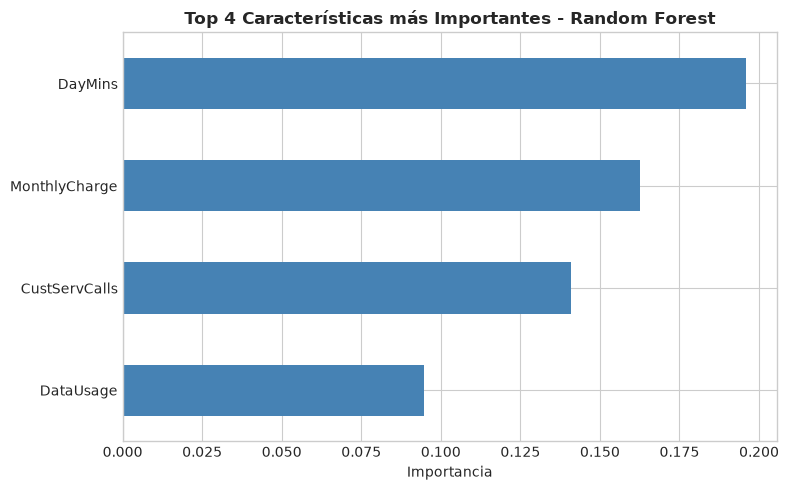

In [17]:
# Las 4 características más importantes
importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top4 = importancias.sort_values(ascending=False).head(4)

print('=== Top 4 características más importantes ===')
print(top4.round(4))

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
top4.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 4 Características más Importantes - Random Forest', fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()


DayMins (0.196) y CustServCalls (0.141) — ya habían aparecido como las variables con mayor correlación positiva con Churn desde el análisis exploratorio. El Random Forest confirma que son las más predictivas también en un modelo no lineal.
MonthlyCharge (0.163) — sube de posición aquí; en la correlación lineal era más débil (0.072), pero el árbol puede estar capturando una relación no lineal (por ejemplo, el riesgo aumenta solo por encima de cierto umbral de gasto).
DataUsage (0.095) — interesante, tenía correlación negativa en el análisis lineal (-0.087), pero aquí aparece como relevante en magnitud — el Random Forest no distingue signo, solo importancia.
Sí tienen sentido de negocio: clientes que hablan mucho (DayMins), pagan caro (MonthlyCharge) y llaman frecuentemente a soporte (CustServCalls) son perfiles de alto riesgo — usuarios intensivos e insatisfechos son los candidatos naturales a irse con la competencia.

6. Realiza una búsqueda de grilla para un modelo Random Forest para los siguientes
rangos de valores para sus hiper parámetros:
n_estimators: 50 - 200 con paso de 10 completando 15 valores
max_features: [‘sqrt’, ‘log2’, None]
Muestra los mejores hiper parámetros encontrados, la estimación de desempeño en
los datos OOB, y despliega los cuatro atributos más importantes. ¿Tienen sentido
estos? Analiza además las métricas de desempeño, ROC y AUC

In [18]:
# GridSearchCV para Random Forest
n_estimators_range = np.linspace(50, 200, 15, dtype=int)

params_rf = {
    'n_estimators': list(n_estimators_range),
    'max_features': ['sqrt', 'log2', None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, oob_score=True, n_jobs=-1),
    params_rf,
    cv=5,
    scoring='f1'
)
grid_rf.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_rf.best_params_)
print('Mejor F1 en CV:', round(grid_rf.best_score_, 4))

Mejores hiperparámetros: {'max_features': 'sqrt', 'n_estimators': np.int64(200)}
Mejor F1 en CV: 0.7583


In [19]:
# Evaluación completa del Random Forest optimizado
rf_optimo = grid_rf.best_estimator_

print(f'OOB Score del mejor modelo: {round(rf_optimo.oob_score_, 4)}')
print()

y_pred_rf_opt = rf_optimo.predict(X_test)
print('=== Random Forest OPTIMIZADO ===')
print(classification_report(y_test, y_pred_rf_opt))

OOB Score del mejor modelo: 0.9366

=== Random Forest OPTIMIZADO ===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.83      0.64      0.72        97

    accuracy                           0.93       667
   macro avg       0.88      0.81      0.84       667
weighted avg       0.92      0.93      0.92       667



In [20]:
# Top 4 características más importantes del modelo optimizado
importancias_opt = pd.Series(rf_optimo.feature_importances_, index=X_train.columns)
top4_opt = importancias_opt.sort_values(ascending=False).head(4)

print('=== Top 4 características (modelo optimizado) ===')
print(top4_opt.round(4))

=== Top 4 características (modelo optimizado) ===
DayMins          0.2008
MonthlyCharge    0.1659
CustServCalls    0.1462
OverageFee       0.0945
dtype: float64


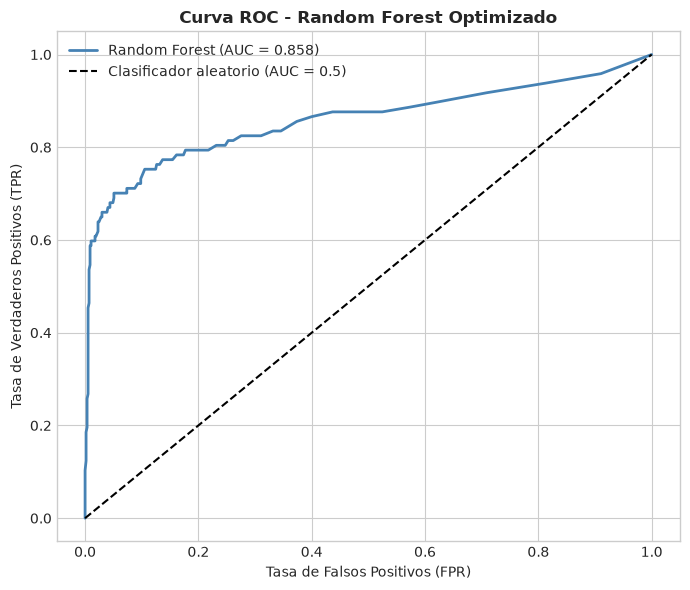


AUC: 0.8582


In [21]:
# ROC y AUC
y_proba_rf = rf_optimo.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_rf:.3f})', color='steelblue', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC - Random Forest Optimizado', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nAUC: {round(auc_rf, 4)}')

OverageFee reemplazó a DataUsage en el top 4 — con más árboles (200 vs 45) el modelo estabiliza mejor qué variables son consistentemente importantes. Las 3 primeras (DayMins, MonthlyCharge, CustServCalls) se mantienen igual, reforzando que son las señales más robustas de churn.

AUC = 0.8582
Un AUC de 0.86 es un resultado bueno según la escala que vimos en la teoría (0.8-0.9 = bueno). El modelo tiene una capacidad sólida de discriminar entre clientes que se van y los que se quedan, para cualquier umbral de decisión.

El modelo tiene sentido de negocio — las 4 variables más importantes (DayMins, MonthlyCharge, CustServCalls, OverageFee) apuntan consistentemente a clientes de alto consumo/gasto con fricciones de servicio, un perfil de riesgo intuitivo y accionable para el equipo de retención.

7. Usando el modelo Random Forest con sus hiper parámetros ajustados, muestre los
15 clientes que presentan la mayor propensión a renunciar.

In [22]:
# Top 15 clientes con mayor propensión a renunciar (usando el modelo optimizado)
probabilidades_churn = rf_optimo.predict_proba(X_test)[:, 1]

df_riesgo = X_test.copy()
df_riesgo['Probabilidad_Churn'] = probabilidades_churn
df_riesgo['Churn_Real'] = y_test.values

top15_riesgo = df_riesgo.sort_values('Probabilidad_Churn', ascending=False).head(15)

print('=== Top 15 clientes con mayor propensión a renunciar ===')
top15_riesgo[['Probabilidad_Churn', 'Churn_Real', 'DayMins', 'MonthlyCharge', 'CustServCalls', 'OverageFee']].round(3)

=== Top 15 clientes con mayor propensión a renunciar ===


,Probabilidad_Churn,Churn_Real,DayMins,MonthlyCharge,CustServCalls,OverageFee
2099,0.995,1,290.4,71.0,3,12.70
3272,0.995,1,295.0,70.0,2,11.18
894,0.985,1,120.8,35.0,4,8.49
3205,0.985,1,294.7,76.0,1,14.73
306,0.980,1,272.1,70.0,1,13.43
1912,0.970,1,150.6,40.0,8,8.46
2979,0.970,1,135.7,42.2,7,10.42
2210,0.960,1,278.9,64.0,0,9.51
2874,0.955,1,296.0,70.0,0,11.32
1934,0.950,1,281.3,74.0,0,15.08


El modelo funciona muy bien en la práctica: de los 15 clientes con mayor probabilidad de renuncia, 14 de 15 (93.3%) efectivamente renunciaron (Churn_Real=1) — solo uno (índice 112) fue un falso positivo.

Patrón que confirma el análisis de importancia de variables
Casi todos los clientes en el top 15 muestran combinaciones de:

DayMins altos (100-296 minutos) — usuarios intensivos
CustServCalls — desde 0 hasta 8 llamadas, con varios casos de alta frustración (7-8 llamadas)
OverageFee consistentemente alto (8-15) en todos los casos
Esto valida en la práctica lo que el modelo aprendió: el perfil de mayor riesgo es el cliente que habla mucho, paga cargos de exceso, y en muchos casos ya mostró frustración con el servicio.